# NYC Building Footprints

This notebook retrieves and explores Manhattan building footprints from NYC Open Data.

## Data Source

- Provider: NYC Office of Technology and Innovation
- Dataset ID: 5zhs-2jue
- Geometry type: Building polygons
- Manhattan filter: BIN between 1000000 and 1999999

In [1]:
from urllib.parse import urlencode

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
base_url = "https://data.cityofnewyork.us/resource/5zhs-2jue.geojson"

params = {
    "$limit": 100,
    "$where": "bin >= 1000000 AND bin < 2000000"
}

api_url = f"{base_url}?{urlencode(params)}"

print(api_url)

https://data.cityofnewyork.us/resource/5zhs-2jue.geojson?%24limit=100&%24where=bin+%3E%3D+1000000+AND+bin+%3C+2000000


In [3]:
buildings = gpd.read_file(api_url)

print("Rows and columns:", buildings.shape)
print("Coordinate system:", buildings.crs)

buildings.head()

Rows and columns: (100, 16)
Coordinate system: EPSG:4326


,name,base_bbl,shape_area,construction_year,ground_elevation,mappluto_bbl,objectid,feature_code,shape_length,height_roof,last_status_type,bin,last_edited_date,geom_source,doitt_id,geometry
0,NaN,1016770046,648.35546875,2026,15,1016770046,1092299,2100,105.16426715851014,80,Constructed,1000000,2026-08-21 13:52:09+00:00,Other (Manual),1306887,"MULTIPOLYGON (((-73.94189 40.79024, -73.94174 ..."
1,NaN,1000010101,9784.015625,1900,16,1000010101,322954,2100,481.1303611660706,119.11,Constructed,1000002,2009-02-14 00:00:00+00:00,Photogrammetric,221574,"MULTIPOLYGON (((-74.04443 40.68967, -74.04433 ..."
2,Battery Maritime Building,1000020002,9121.35546875,1900,-1,1000020002,1070584,2100,437.64485363039591,71,Constructed,1000003,2017-08-22 18:15:22+00:00,Other (Manual),703016,"MULTIPOLYGON (((-74.01129 40.70126, -74.01121 ..."
3,NaN,1000030010,1393.0390625,1960,9,1000030010,746467,2100,212.53176082085298,44.19,Constructed,1000004,2017-08-22 17:44:36+00:00,Photogrammetric,249492,"MULTIPOLYGON (((-74.01403 40.70106, -74.01406 ..."
4,1 New York Plaza,1000040001,9703.2109375,1969,6,1000047501,53255,2100,408.61763864849178,662,Constructed,1000005,2017-08-22 17:38:21+00:00,Other (Manual),426732,"MULTIPOLYGON (((-74.01154 40.70196, -74.01152 ..."


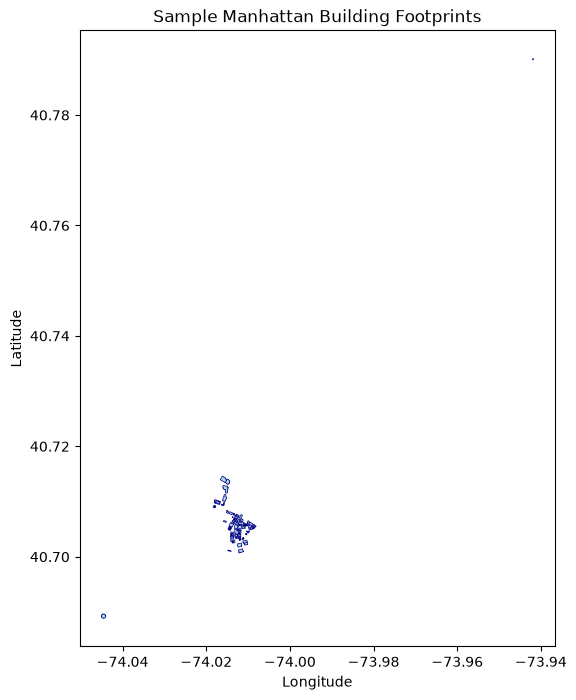

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

buildings.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="navy",
    linewidth=0.5
)

ax.set_title("Sample Manhattan Building Footprints")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [5]:
columns_to_check = [
    "bin",
    "construction_year",
    "ground_elevation",
    "height_roof",
    "geometry"
]

print("Data types:")
print(buildings[columns_to_check].dtypes)

print("\nMissing values:")
print(buildings[columns_to_check].isna().sum())

buildings[columns_to_check].head(10)

Data types:
bin                       str
construction_year         str
ground_elevation          str
height_roof               str
geometry             geometry
dtype: object

Missing values:
bin                  0
construction_year    1
ground_elevation     0
height_roof          0
geometry             0
dtype: int64


,bin,construction_year,ground_elevation,height_roof,geometry
0,1000000,2026,15,80,"MULTIPOLYGON (((-73.94189 40.79024, -73.94174 ..."
1,1000002,1900,16,119.11,"MULTIPOLYGON (((-74.04443 40.68967, -74.04433 ..."
2,1000003,1900,-1,71,"MULTIPOLYGON (((-74.01129 40.70126, -74.01121 ..."
3,1000004,1960,9,44.19,"MULTIPOLYGON (((-74.01403 40.70106, -74.01406 ..."
4,1000005,1969,6,662,"MULTIPOLYGON (((-74.01154 40.70196, -74.01152 ..."
5,1000006,1970,6,511,"MULTIPOLYGON (((-74.01093 40.70248, -74.01028 ..."
6,1000007,1969,9,303.14,"MULTIPOLYGON (((-74.01022 40.7026, -74.01028 4..."
7,1000008,1828,8,53.92,"MULTIPOLYGON (((-74.01097 40.70324, -74.01103 ..."
8,1000009,1828,7,50.34,"MULTIPOLYGON (((-74.01103 40.70323, -74.01103 ..."
9,1000010,1828,7,46.58,"MULTIPOLYGON (((-74.0111 40.70321, -74.01116 4..."


In [6]:
numeric_columns = [
    "construction_year",
    "ground_elevation",
    "height_roof"
]

for column in numeric_columns:
    buildings[column] = pd.to_numeric(
        buildings[column],
        errors="coerce"
    )

buildings["construction_year"] = (
    buildings["construction_year"].astype("Int64")
)

print(buildings[columns_to_check].dtypes)

print("\nGeometry types:")
print(buildings.geometry.geom_type.value_counts())

print("\nValid geometries:")
print(buildings.geometry.is_valid.value_counts())


bin                       str
construction_year       Int64
ground_elevation        int64
height_roof           float64
geometry             geometry
dtype: object

Geometry types:
MultiPolygon    100
Name: count, dtype: int64

Valid geometries:
True    100
Name: count, dtype: int64


## Count Manhattan Building Records

Before downloading the full dataset, query the number of Manhattan building records.

In [7]:
count_base_url = (
    "https://data.cityofnewyork.us/resource/5zhs-2jue.json"
)

count_params = {
    "$select": "count(*) AS total",
    "$where": "bin >= 1000000 AND bin < 2000000"
}

count_url = f"{count_base_url}?{urlencode(count_params)}"

count_result = pd.read_json(count_url)
total_buildings = int(count_result.loc[0, "total"])

print(f"Manhattan building records: {total_buildings:,}")

Manhattan building records: 45,195


## Download All Manhattan Building Footprints

The API data is downloaded in pages to avoid request-size limits.
Records are ordered by `objectid` to keep pagination stable.

In [8]:
page_size = 5000
pages = []

for offset in range(0, total_buildings, page_size):
    page_params = {
        "$limit": page_size,
        "$offset": offset,
        "$where": "bin >= 1000000 AND bin < 2000000",
        "$order": "objectid"
    }

    page_url = f"{base_url}?{urlencode(page_params)}"
    page = gpd.read_file(page_url)

    pages.append(page)

    print(
        f"Downloaded {offset + 1:,} "
        f"to {offset + len(page):,}"
    )

Downloaded 1 to 5,000
Downloaded 5,001 to 10,000
Downloaded 10,001 to 15,000
Downloaded 15,001 to 20,000
Downloaded 20,001 to 25,000
Downloaded 25,001 to 30,000
Downloaded 30,001 to 35,000
Downloaded 35,001 to 40,000
Downloaded 40,001 to 45,000
Downloaded 45,001 to 45,195


In [9]:
manhattan_buildings = gpd.GeoDataFrame(
    pd.concat(pages, ignore_index=True),
    geometry="geometry",
    crs=pages[0].crs
)

print("Rows and columns:", manhattan_buildings.shape)
print("Coordinate system:", manhattan_buildings.crs)

print(
    "Duplicate object IDs:",
    manhattan_buildings["objectid"].duplicated().sum()
)

print(
    "Missing geometries:",
    manhattan_buildings.geometry.isna().sum()
)

print(
    "Invalid geometries:",
    (~manhattan_buildings.geometry.is_valid).sum()
)

Rows and columns: (45195, 16)
Coordinate system: EPSG:4326
Duplicate object IDs: 0
Missing geometries: 0
Invalid geometries: 4


In [10]:
from shapely.validation import explain_validity

invalid_mask = ~manhattan_buildings.geometry.is_valid

invalid_buildings = (
    manhattan_buildings.loc[invalid_mask].copy()
)

invalid_buildings["validity_issue"] = (
    invalid_buildings.geometry.apply(explain_validity)
)

invalid_buildings[
    ["objectid", "bin", "validity_issue", "geometry"]
]

,objectid,bin,validity_issue,geometry
3707,84928,1052645,Ring Self-intersection[-73.944423686529 40.786...,"MULTIPOLYGON (((-73.94458 40.78626, -73.94474 ..."
3842,87046,1007816,Ring Self-intersection[-74.003625525124 40.725...,"MULTIPOLYGON (((-74.00365 40.7255, -74.00366 4..."
14420,413374,1043029,Ring Self-intersection[-73.962347038608 40.771...,"MULTIPOLYGON (((-73.96241 40.77175, -73.96235 ..."
29099,862980,1082062,Ring Self-intersection[-73.915388177829 40.870...,"MULTIPOLYGON (((-73.9154 40.87061, -73.91539 4..."


In [11]:
repaired_geometries = (
    manhattan_buildings.loc[invalid_mask, "geometry"]
    .make_valid()
)

print("Validity after repair:")
print(repaired_geometries.is_valid.value_counts())

print("\nGeometry types after repair:")
print(repaired_geometries.geom_type.value_counts())

Validity after repair:
True    4
Name: count, dtype: int64

Geometry types after repair:
Polygon    4
Name: count, dtype: int64


## Save Raw Building Data

Save the original Manhattan building footprints before applying any cleaning or transformation.

In [12]:
from pathlib import Path

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

raw_data_path = (
    project_root
    / "data"
    / "raw"
    / "manhattan_building_footprints_raw.gpkg"
)

manhattan_buildings.to_file(
    raw_data_path,
    layer="building_footprints",
    driver="GPKG"
)

print("Saved to:", raw_data_path)
print("File exists:", raw_data_path.exists())
print(
    "File size:",
    round(raw_data_path.stat().st_size / 1_000_000, 2),
    "MB"
)

Saved to: c:\Users\Owner\Desktop\曼岛flood risk\manhattan-pluvial-flood-risk\data\raw\manhattan_building_footprints_raw.gpkg
File exists: True
File size: 24.35 MB


## Clean Building Data

Create a separate copy for cleaning while preserving the raw data.

In [13]:
buildings_clean = manhattan_buildings.copy()

# Replace four invalid geometries
buildings_clean.loc[
    invalid_mask,
    "geometry"
] = repaired_geometries

measurement_columns = [
    "construction_year",
    "ground_elevation",
    "height_roof",
    "shape_area"
]

for column in measurement_columns:
    buildings_clean[column] = pd.to_numeric(
        buildings_clean[column],
        errors="coerce"
    )

buildings_clean["construction_year"] = (
    buildings_clean["construction_year"].astype("Int64")
)

print("Data types:")
print(buildings_clean[measurement_columns].dtypes)

print("\nMissing values:")
print(buildings_clean[measurement_columns].isna().sum())

print(
    "\nInvalid geometries:",
    (~buildings_clean.geometry.is_valid).sum()
)

Data types:
construction_year      Int64
ground_elevation     float64
height_roof          float64
shape_area           float64
dtype: object

Missing values:
construction_year    828
ground_elevation      59
height_roof            0
shape_area             0
dtype: int64

Invalid geometries: 0


In [14]:
summary_statistics = (
    buildings_clean[measurement_columns]
    .describe(
        percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
    )
    .transpose()
)

summary_statistics

,count,mean,std,min,1%,5%,50%,95%,99%,max
construction_year,44367.0,1916.851173,36.551537,1719.0,1833.0,1860.0,1910.0,2001.0,2019.0,2026.0
ground_elevation,45136.0,48.364543,39.380723,-16.0,7.0,10.0,35.0,125.0,191.0,273.0
height_roof,45195.0,76.35803,73.78868,0.0,11.0,23.917673,58.22,194.479,412.0036,1550.0
shape_area,45195.0,749.821371,1896.633364,8.144531,63.225547,122.411328,317.796875,2486.894531,6376.04375,190324.050781


In [15]:
quality_checks = pd.Series({
    "construction_year below 1600":
        (buildings_clean["construction_year"] < 1600).sum(),

    "construction_year after 2026":
        (buildings_clean["construction_year"] > 2026).sum(),

    "ground_elevation below 0":
        (buildings_clean["ground_elevation"] < 0).sum(),

    "height_roof less than or equal to 0":
        (buildings_clean["height_roof"] <= 0).sum(),

    "shape_area less than or equal to 0":
        (buildings_clean["shape_area"] <= 0).sum()
})

quality_checks

construction_year below 1600            0
construction_year after 2026            0
ground_elevation below 0               11
height_roof less than or equal to 0    75
shape_area less than or equal to 0      0
dtype: int64

In [16]:
zero_height_buildings = buildings_clean.loc[
    buildings_clean["height_roof"] <= 0,
    [
        "bin",
        "feature_code",
        "geom_source",
        "ground_elevation",
        "height_roof",
        "geometry"
    ]
].copy()

print(
    "Zero-height buildings:",
    len(zero_height_buildings)
)

print("\nFeature-code counts:")
print(
    zero_height_buildings["feature_code"]
    .value_counts(dropna=False)
)

zero_height_buildings.head(10)

Zero-height buildings: 75

Feature-code counts:
feature_code
2100    45
1004     7
5100     6
1003     6
1000     4
5110     4
2110     2
1001     1
Name: count, dtype: int64


,bin,feature_code,geom_source,ground_elevation,height_roof,geometry
2312,1090162,2100,Other (Manual),8.0,0.0,"MULTIPOLYGON (((-74.00588 40.74558, -74.00604 ..."
2853,1012254,1000,Other (Manual),NaN,0.0,"MULTIPOLYGON (((-74.00929 40.75054, -74.0094 4..."
2855,1089349,1000,Other (Manual),NaN,0.0,"MULTIPOLYGON (((-73.9602 40.75109, -73.96009 4..."
3032,1090615,2100,Other (Manual),78.0,0.0,"MULTIPOLYGON (((-73.97598 40.75813, -73.97592 ..."
3035,1084663,2100,Other (Manual),38.0,0.0,"MULTIPOLYGON (((-73.98862 40.73936, -73.98859 ..."
3087,1090627,5100,Photogrammetric,54.0,0.0,"MULTIPOLYGON (((-73.98669 40.75159, -73.98688 ..."
3258,1089795,2100,Other (Manual),34.0,0.0,"MULTIPOLYGON (((-73.98794 40.7294, -73.98792 4..."
3264,1090424,2100,Other (Manual),9.0,0.0,"MULTIPOLYGON (((-73.95614 40.82494, -73.95678 ..."
3280,1795013,2110,Other (Manual),NaN,0.0,"MULTIPOLYGON (((-74.01245 40.70828, -74.01271 ..."
3323,1089089,5110,Other (Manual),26.0,0.0,"MULTIPOLYGON (((-73.92773 40.78851, -73.92764 ..."


In [17]:
negative_elevation_buildings = buildings_clean.loc[
    buildings_clean["ground_elevation"] < 0,
    [
        "bin",
        "feature_code",
        "geom_source",
        "ground_elevation",
        "height_roof",
        "geometry"
    ]
].copy()

print(
    "Negative-elevation buildings:",
    len(negative_elevation_buildings)
)

negative_elevation_buildings 

Negative-elevation buildings: 11


,bin,feature_code,geom_source,ground_elevation,height_roof,geometry
3051,1086486,2100,Other (Manual),-2.0,42.000000,"MULTIPOLYGON (((-73.92153 40.85661, -73.9216 4..."
3214,1088844,2100,Photogrammetric,-4.0,132.465952,"MULTIPOLYGON (((-73.99793 40.73009, -73.99812 ..."
3558,1089469,2100,Photogrammetric,-1.0,32.299154,"MULTIPOLYGON (((-74.00383 40.75949, -74.00386 ..."
16489,1085962,2100,Other (Manual),-6.0,673.000000,"MULTIPOLYGON (((-73.99871 40.7608, -73.99871 4..."
37192,1075697,2100,Other (Manual),-1.0,37.000000,"MULTIPOLYGON (((-74.00921 40.70138, -74.00932 ..."
37468,1051489,2100,Other (Manual),-6.0,560.000000,"MULTIPOLYGON (((-73.95217 40.791, -73.95258 40..."
43513,1000003,2100,Other (Manual),-1.0,71.000000,"MULTIPOLYGON (((-74.01129 40.70126, -74.01121 ..."
44032,1089799,2100,Photogrammetric,-2.0,21.029465,"MULTIPOLYGON (((-73.93268 40.86725, -73.93268 ..."
44410,1087678,2100,Other (Manual),-5.0,143.000000,"MULTIPOLYGON (((-73.99904 40.76048, -73.99895 ..."
44503,1089438,2100,Other (Manual),-11.0,87.000000,"MULTIPOLYGON (((-73.99961 40.76187, -73.99945 ..."


## Add Data Quality Flags

Preserve questionable records while creating flags that document missing, repaired, or unusual values.

In [18]:
buildings_clean["geometry_repaired"] = invalid_mask

buildings_clean["construction_year_missing"] = (
    buildings_clean["construction_year"].isna()
)

buildings_clean["ground_elevation_missing"] = (
    buildings_clean["ground_elevation"].isna()
)

buildings_clean["ground_elevation_negative"] = (
    buildings_clean["ground_elevation"] < 0
)

buildings_clean["height_roof_missing"] = (
    buildings_clean["height_roof"] <= 0
)

buildings_clean.loc[
    buildings_clean["height_roof_missing"],
    "height_roof"
] = float("nan")

print("Geometry repaired:")
print(buildings_clean["geometry_repaired"].sum())

print("\nConstruction year missing:")
print(buildings_clean["construction_year_missing"].sum())

print("\nGround elevation missing:")
print(buildings_clean["ground_elevation_missing"].sum())

print("\nGround elevation negative:")
print(buildings_clean["ground_elevation_negative"].sum())

print("\nRoof height missing:")
print(buildings_clean["height_roof_missing"].sum())

Geometry repaired:
4

Construction year missing:
828

Ground elevation missing:
59

Ground elevation negative:
11

Roof height missing:
75


## Project Buildings and Calculate Footprint Area

Reproject the building geometries to EPSG:2263 before calculating area in square feet.

In [19]:
buildings_projected = buildings_clean.to_crs(
    "EPSG:2263"
)

buildings_projected["footprint_area_sqft"] = (
    buildings_projected.geometry.area
)

buildings_projected["area_ratio"] = (
    buildings_projected["footprint_area_sqft"]
    / buildings_projected["shape_area"]
)

print("Original CRS:", buildings_clean.crs)
print("Projected CRS:", buildings_projected.crs)

print("\nCalculated footprint area:")
print(
    buildings_projected["footprint_area_sqft"]
    .describe()
)

print("\nCalculated area / source shape_area:")
print(
    buildings_projected["area_ratio"]
    .describe()
)

Original CRS: EPSG:4326
Projected CRS: EPSG:2263

Calculated footprint area:
count    4.519500e+04
mean     4.624431e+03
std      1.169389e+04
min      5.019290e+01
25%      1.233647e+03
50%      1.960673e+03
75%      4.467487e+03
max      1.171875e+06
Name: footprint_area_sqft, dtype: float64

Calculated area / source shape_area:
count    45195.000000
mean         6.167310
std          0.007301
min          6.146541
25%          6.161904
50%          6.167810
75%          6.173668
max          6.183616
Name: area_ratio, dtype: float64


## Save Processed Building Data

Store cleaned and projected building footprints with consistently defined area fields.

In [20]:
SQUARE_FEET_TO_SQUARE_METERS = 0.09290304

buildings_projected["footprint_area_sqm"] = (
    buildings_projected["footprint_area_sqft"]
    * SQUARE_FEET_TO_SQUARE_METERS
)

buildings_projected = buildings_projected.drop(
    columns=["area_ratio"]
)

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "manhattan_building_footprints_processed.gpkg"
)

buildings_projected.to_file(
    processed_data_path,
    layer="building_footprints",
    driver="GPKG"
)

print("Saved to:", processed_data_path)
print("File exists:", processed_data_path.exists())
print(
    "File size:",
    round(
        processed_data_path.stat().st_size / 1_000_000,
        2
    ),
    "MB"
)

print("Rows:", len(buildings_projected))
print("CRS:", buildings_projected.crs)

Saved to: c:\Users\Owner\Desktop\曼岛flood risk\manhattan-pluvial-flood-risk\data\processed\manhattan_building_footprints_processed.gpkg
File exists: True
File size: 25.28 MB
Rows: 45195
CRS: EPSG:2263


## Manhattan Building Footprint Map

Visualize all cleaned Manhattan building footprints using the projected geometry.

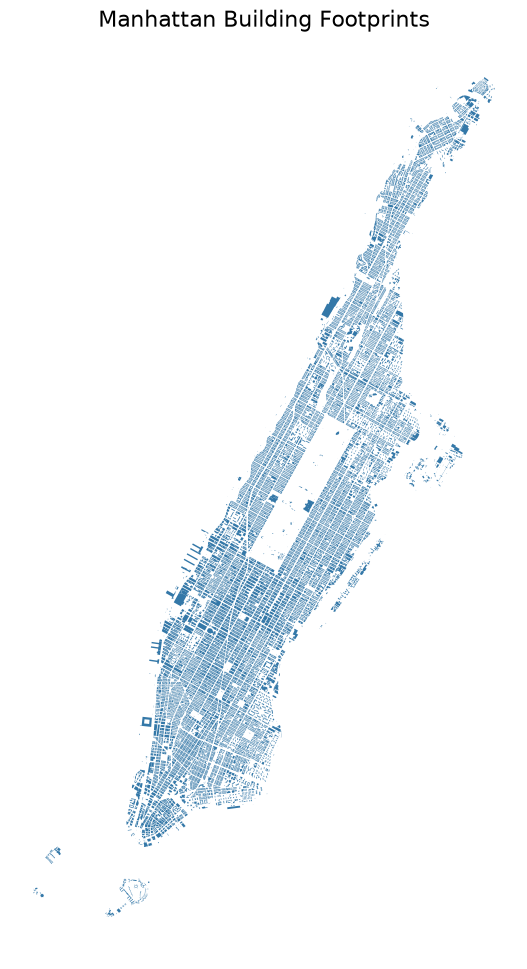

Figure saved to: c:\Users\Owner\Desktop\曼岛flood risk\manhattan-pluvial-flood-risk\outputs\manhattan_building_footprints.png
File exists: True


In [21]:
figure_path = (
    project_root
    / "outputs"
    / "manhattan_building_footprints.png"
)

fig, ax = plt.subplots(
    figsize=(8, 12)
)

buildings_projected.plot(
    ax=ax,
    color="#3478A8",
    edgecolor="none"
)

ax.set_title(
    "Manhattan Building Footprints",
    fontsize=16
)

ax.set_axis_off()

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", figure_path)
print("File exists:", figure_path.exists())

## Summary

- Retrieved 45,195 Manhattan building records from NYC Open Data.
- Preserved the original records in a raw GeoPackage.
- Converted analytical fields from text to numeric values.
- Identified and repaired four self-intersecting geometries.
- Flagged missing roof heights, construction years, and ground elevations.
- Preserved negative ground elevations for later comparison with an independent DEM.
- Reprojected the buildings from EPSG:4326 to EPSG:2263.
- Calculated building footprint area in square feet and square meters.
- Saved the cleaned building data and a Manhattan building footprint map.